In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.Label_Transfer import CellAnnotator
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### Pre-training data using one slice

In [4]:
adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata.var_names_make_unique()
adata.obs['type']='Pre-training data'

In [5]:
sc.pp.scale(adata)
adata.obsm['feat']=adata.X

In [6]:
k=16
graph = prepare_inputs(adata, k, device)

In [7]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 47.99it/s, Epoch=199, Loss=0.9014]


In [9]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [10]:
adata.obsm['SpaLP']=embedding

In [11]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth")

In [12]:
adata.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/Pre-training.h5ad',compression='gzip')

### Inference data using two slices

In [13]:
adata1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata1.var_names_make_unique()
adata1.obs['type']='Inference data1'

adata2=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.077.h5ad')
adata2.var_names_make_unique()
adata2.obs['type']='Inference data2'

In [14]:
sc.pp.scale(adata1)
adata1.obsm['feat']=adata1.X

sc.pp.scale(adata2)
adata2.obsm['feat']=adata2.X

In [15]:
graph1 = prepare_inputs(adata1, k=16, device=device)
graph2 = prepare_inputs(adata2, k=16, device=device)

### zero-shot inference embedding

In [16]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata1.obsm['SpaLP']=embedding

In [17]:
in_channels = graph2.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph2.features, graph2.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata2.obsm['SpaLP']=embedding

### Train the classifier using the pre-training data

In [18]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/Pre-training.h5ad')

In [19]:
annotator = CellAnnotator(device=device)

annotator.train(Pre_train_adata, embed_key='SpaLP', label_key='major_brain_region', epochs=200,batch_size=2048)

Loading data from .obsm['SpaLP'] and .obs['major_brain_region']...
Start training on cuda:0...


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:58<00:00,  3.45it/s, Epoch=199, CrossEntropyLoss=0.0341, Best Acc=96.5852]

Calibrating model using Temperature Scaling...
ECE before calibration: 0.0149
Optimal Temperature found: 1.1063
ECE after calibration: 0.0140
Training completed.


### Predict the label and uncertainty of inference data 1

In [20]:
annotator.predict(adata1, embed_key='SpaLP', save_key='predicted_Label')

Predictions saved to adata.obs['predicted_Label']
uncertainty saved to adata.obs['predicted_Label_uncertainty_uncalibrated']
Calibrated uncertainty saved to adata.obs['predicted_Label_uncertainty_calibrated']


AnnData object with n_obs × n_vars = 42854 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', '

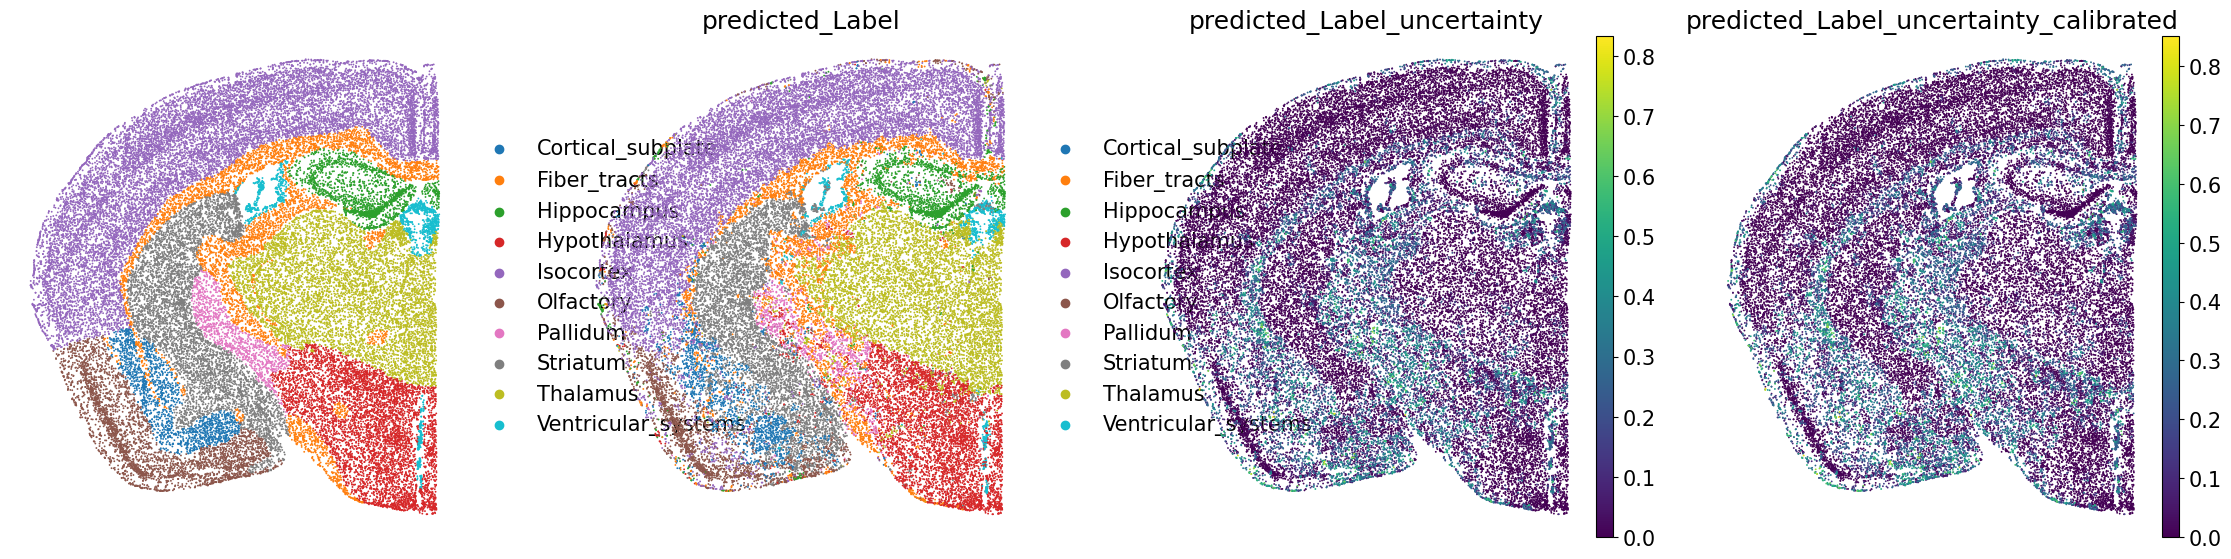

In [21]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1, basis="spatial",s=7,color=['major_brain_region','predicted_Label','predicted_Label_uncertainty','predicted_Label_uncertainty_calibrated'],title='',frameon=False)

### Clustering metrics

In [30]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata1.obs['major_brain_region'])
cluster_labels = np.array(adata1.obs['predicted_Label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.7318677562007193
NMI: 0.6386474497788652
AMI: 0.6384782995052918
FMI: 0.7756923511699099
V-Measure: 0.6386474497788652
Homogeneity: 0.6354797352751614


### Uncertainty and calibration analysis of mispredictions

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

true_label_col = 'major_brain_region' 
pred_label_col = 'predicted_Label'
uncalib_col = 'predicted_Label_uncertainty' 
calib_col = 'predicted_Label_uncertainty_calibrated'

is_incorrect = adata1.obs[true_label_col] != adata1.obs[pred_label_col]
incorrect_obs = adata1.obs[is_incorrect]

print(f"Total {len(incorrect_obs)} Predicting wrong cells")

uncalib_uncert = incorrect_obs[uncalib_col].values
calib_uncert = incorrect_obs[calib_col].values


mean_uncalib = np.mean(uncalib_uncert)
mean_calib = np.mean(calib_uncert)
print(f"【Predicting wrong cells】Average uncertainty before calibration: {mean_uncalib:.4f}")
print(f"【Predicting wrong cells】Average uncertainty after calibration: {mean_calib:.4f}")

stat, p_value = stats.wilcoxon(uncalib_uncert, calib_uncert)
print(f"p-value: {p_value:.2e}")

Total 7965 Predicting wrong cells
【Predicting wrong cells】Average uncertainty before calibration: 0.2058
【Predicting wrong cells】Average uncertainty after calibration: 0.2266
p-value: 0.00e+00


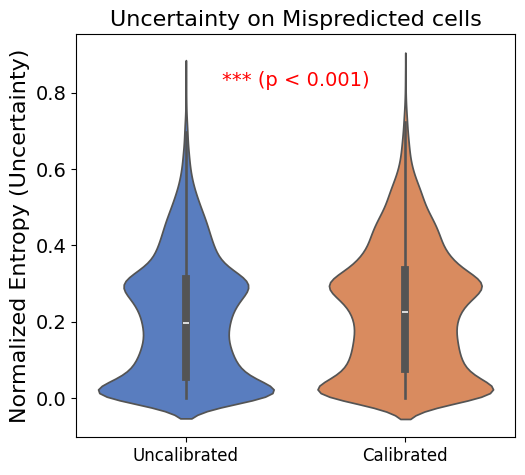

In [60]:
plot_df = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert, calib_uncert]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert) + ['Calibrated'] * len(calib_uncert)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df, palette="muted", inner="box")

plt.title('Uncertainty on Mispredicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value < 0.001:
    plt.text(0.5, plot_df['Uncertainty'].max() * 0.95, '*** (p < 0.001)', ha='center', va='bottom', fontsize=14, color='red')

plt.tight_layout()
#plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/76mispredicted.png", dpi=600)
plt.show()

### Uncertainty and calibration analysis of correct predictions

In [71]:
is_correct = adata1.obs[true_label_col] == adata1.obs[pred_label_col]
correct_obs = adata1.obs[is_correct]
print(f"Total {len(correct_obs)} Predicting correct cells")
uncalib_uncert_right = correct_obs[uncalib_col].values
calib_uncert_right = correct_obs[calib_col].values

mean_uncalib_right = np.mean(uncalib_uncert_right)
mean_calib_right = np.mean(calib_uncert_right)

print(f"【Predicting right cells】Average uncertainty before calibration: {mean_uncalib_right:.4f}")
print(f"【Predicting right cells】Average uncertainty after calibration: {mean_calib_right:.4f}")
stat_right, p_value_correct = stats.wilcoxon(uncalib_uncert_right, calib_uncert_right)
print(f"right p-value: {p_value_correct:.2e}")

Total 34889 Predicting correct cells
【Predicting right cells】Average uncertainty before calibration: 0.0457
【Predicting right cells】Average uncertainty after calibration: 0.0528
right p-value: 0.00e+00


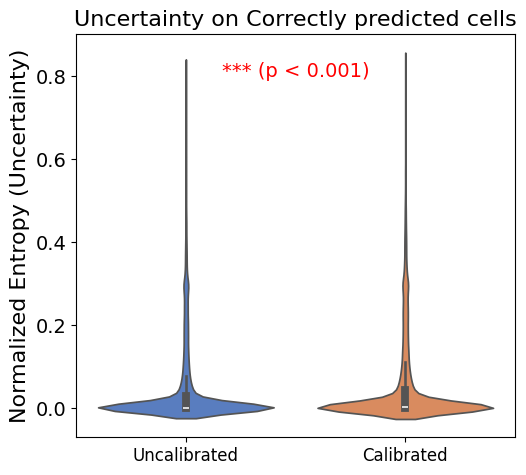

In [62]:
plot_df_correct = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert_right, calib_uncert_right]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert_right) + ['Calibrated'] * len(calib_uncert_right)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df_correct, palette="muted", inner="box")
plt.title('Uncertainty on Correctly predicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value_correct < 0.001:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, '*** (p < 0.001)', 
             ha='center', va='bottom', fontsize=14, color='red')
else:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, f'ns (p = {p_value_correct:.2f})', 
             ha='center', va='bottom', fontsize=14, color='black')

plt.tight_layout()
#plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/76correct predicted.png", dpi=600)
plt.show()

### Predict the label and uncertainty of inference data 2

In [64]:
annotator.predict(adata2, embed_key='SpaLP', save_key='predicted_Label')

Predictions saved to adata.obs['predicted_Label']
uncertainty saved to adata.obs['predicted_Label_uncertainty_uncalibrated']
Calibrated uncertainty saved to adata.obs['predicted_Label_uncertainty_calibrated']


AnnData object with n_obs × n_vars = 43968 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', '

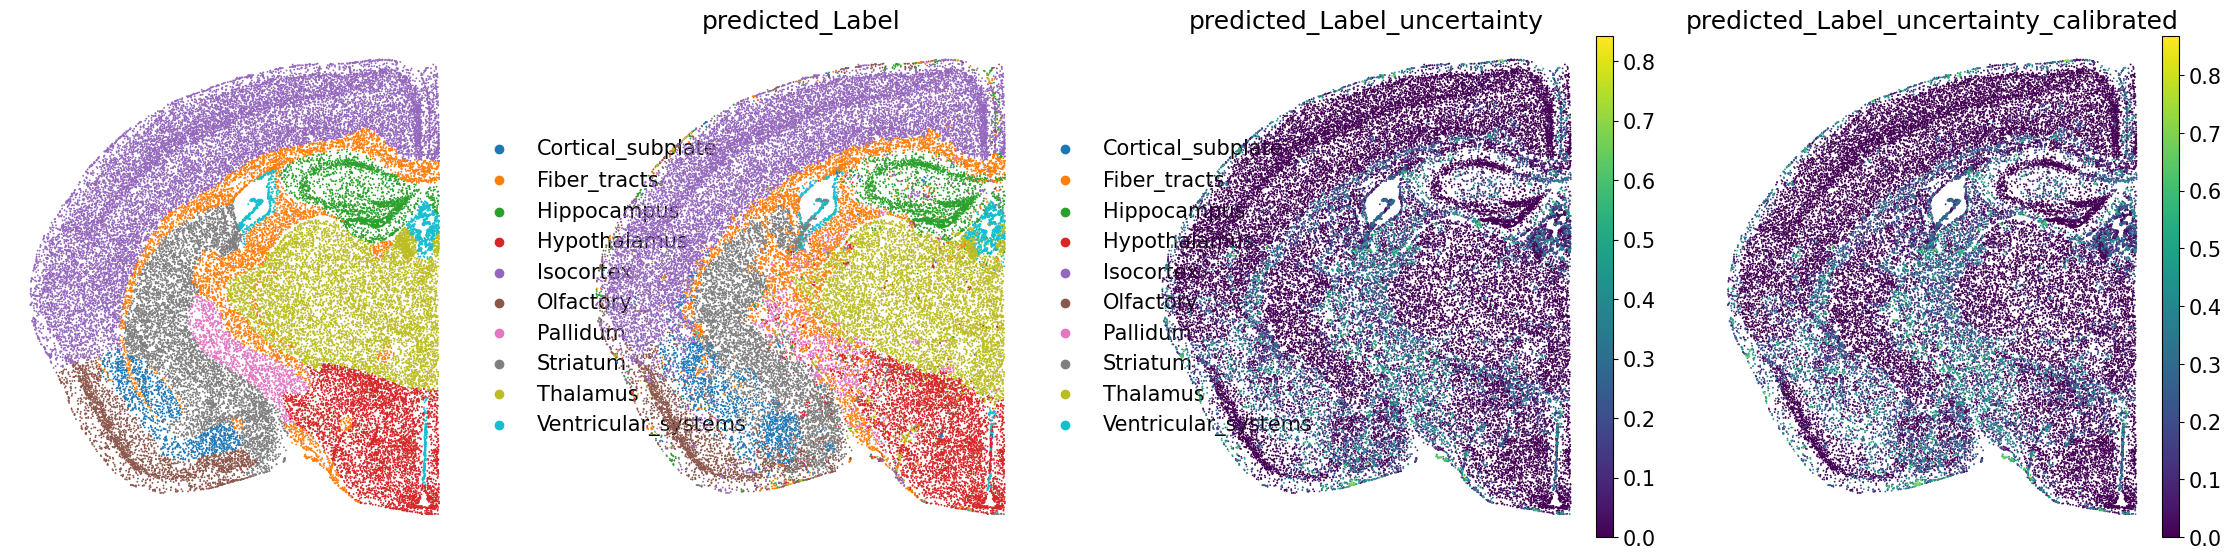

In [65]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata2, basis="spatial",s=7,color=['major_brain_region','predicted_Label','predicted_Label_uncertainty','predicted_Label_uncertainty_calibrated'],title='',frameon=False)

In [66]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata2.obs['major_brain_region'])
cluster_labels = np.array(adata2.obs['predicted_Label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.7417976241753105
NMI: 0.6400164793095873
AMI: 0.6398510495032572
FMI: 0.7853160926816168
V-Measure: 0.6400164793095872
Homogeneity: 0.6432822997076346


In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

true_label_col = 'major_brain_region' 
pred_label_col = 'predicted_Label'
uncalib_col = 'predicted_Label_uncertainty' 
calib_col = 'predicted_Label_uncertainty_calibrated'

is_incorrect = adata2.obs[true_label_col] != adata2.obs[pred_label_col]
incorrect_obs = adata2.obs[is_incorrect]

print(f"Total {len(incorrect_obs)} Predicting wrong cells")

uncalib_uncert = incorrect_obs[uncalib_col].values
calib_uncert = incorrect_obs[calib_col].values


mean_uncalib = np.mean(uncalib_uncert)
mean_calib = np.mean(calib_uncert)
print(f"【Predicting wrong cells】Average uncertainty before calibration: {mean_uncalib:.4f}")
print(f"【Predicting wrong cells】Average uncertainty after calibration: {mean_calib:.4f}")

stat, p_value = stats.wilcoxon(uncalib_uncert, calib_uncert)
print(f"p-value: {p_value:.2e}")

Total 7960 Predicting wrong cells
【Predicting wrong cells】Average uncertainty before calibration: 0.2015
【Predicting wrong cells】Average uncertainty after calibration: 0.2214
p-value: 0.00e+00


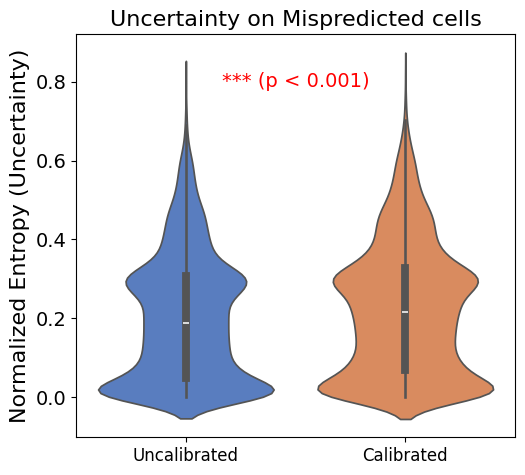

In [68]:
plot_df = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert, calib_uncert]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert) + ['Calibrated'] * len(calib_uncert)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df, palette="muted", inner="box")

plt.title('Uncertainty on Mispredicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value < 0.001:
    plt.text(0.5, plot_df['Uncertainty'].max() * 0.95, '*** (p < 0.001)', ha='center', va='bottom', fontsize=14, color='red')

plt.tight_layout()
plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/77mispredicted.png", dpi=600)
plt.show()

In [70]:
is_correct = adata2.obs[true_label_col] == adata2.obs[pred_label_col]
correct_obs = adata2.obs[is_correct]
print(f"Total {len(correct_obs)} Predicting correct cells")
uncalib_uncert_right = correct_obs[uncalib_col].values
calib_uncert_right = correct_obs[calib_col].values

mean_uncalib_right = np.mean(uncalib_uncert_right)
mean_calib_right = np.mean(calib_uncert_right)

print(f"【Predicting right cells】Average uncertainty before calibration: {mean_uncalib_right:.4f}")
print(f"【Predicting right cells】Average uncertainty after calibration: {mean_calib_right:.4f}")
stat_right, p_value_correct = stats.wilcoxon(uncalib_uncert_right, calib_uncert_right)
print(f"right p-value: {p_value_correct:.2e}")

Total 36008 Predicting correct cells
【Predicting right cells】Average uncertainty before calibration: 0.0451
【Predicting right cells】Average uncertainty after calibration: 0.0520
right p-value: 0.00e+00


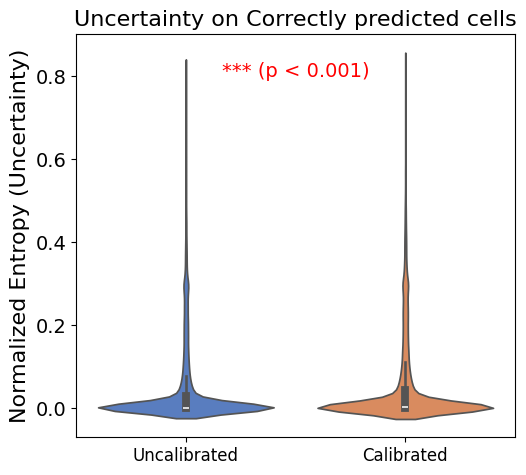

In [72]:
plot_df_correct = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert_right, calib_uncert_right]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert_right) + ['Calibrated'] * len(calib_uncert_right)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df_correct, palette="muted", inner="box")
plt.title('Uncertainty on Correctly predicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value_correct < 0.001:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, '*** (p < 0.001)', 
             ha='center', va='bottom', fontsize=14, color='red')
else:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, f'ns (p = {p_value_correct:.2f})', 
             ha='center', va='bottom', fontsize=14, color='black')

plt.tight_layout()
plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/77correct predicted.png", dpi=600)
plt.show()

In [74]:
sc.settings.figdir = '/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting1/'
sc.settings.set_figure_params(dpi_save=150)

In [75]:
adata2

AnnData object with n_obs × n_vars = 43968 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', '

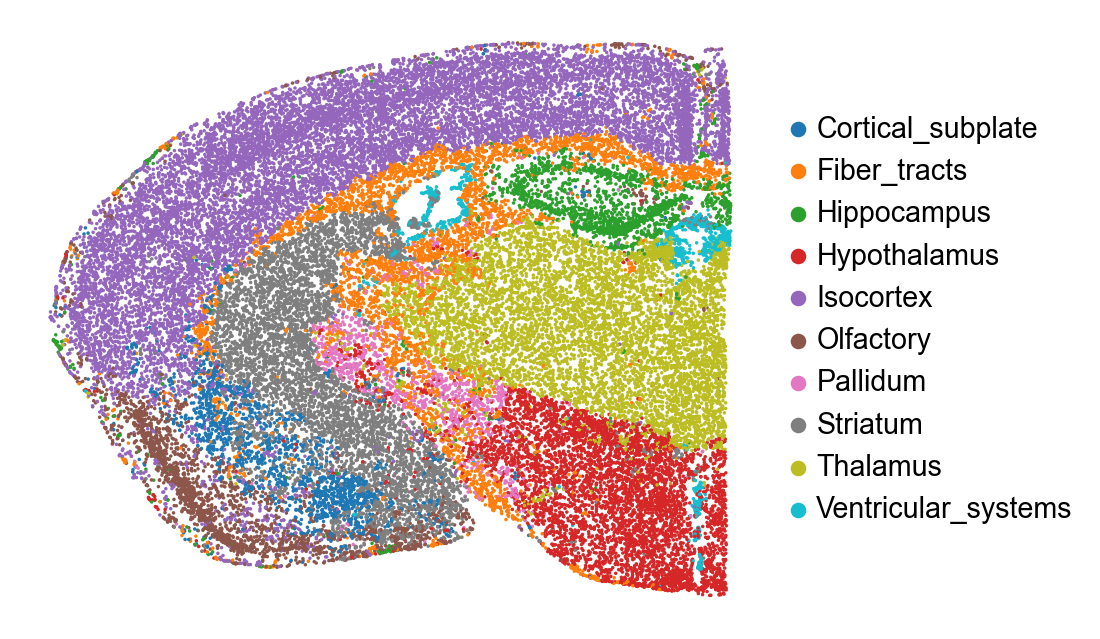

In [83]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1,color='predicted_Label',basis='spatial',s=10,title='',frameon=False,save='76prelabel.png')#,save='pre_train.png')